# 🔗 承上启下：从 264「预训练」到 265「微调」

> 上一章（264）你**从零预训练**了一个 BERT，并想通了"为什么 MLM+NSP 能实现迁移"。这一章（265）就是那套理论的**实战落地**——把预训练好的 BERT **迁移**到一个真实任务上。

## 一、两章的关系：一条迁移学习的完整链路

```
┌─────────────── 264 预训练 ───────────────┐   ┌──────────── 265 微调 ────────────┐
                                            │   │
 海量无标注文本(WikiText-2)                  │   │  带标注任务数据(SNLI 句子对)
   │ MLM + NSP 自监督                        │   │    │ 监督学习(三分类)
   ▼                                        │   │    ▼
 BERTEncoder 学到「通用语言表示」  ──────────┼───┼──► 复用编码器 + 换新任务头
   │                                        │   │    │
   └─ 附带 MLM头、NSP头（预训练用完即弃）      │   │    └─ 新增 nn.Linear(256,3) 分类头
                                            │   │       少量数据微调即可
└────────────────────────────────────────┘   └──────────────────────────────────┘
```

> 💡 **这正是你在 264 第「🧩 为什么能迁移」一节学到的范式**：留下编码器、丢掉预训练任务头、接上新任务头。265 把它变成了可运行的代码。

## 二、关键对照：264 学的概念 → 265 怎么用

| 264 学到的 | 265 里对应的代码 | 说明 |
|-----------|----------------|------|
| 「编码器才是要迁移的」 | `self.encoder = bert.encoder` | 直接复用预训练编码器 |
| 「丢掉 MLM/NSP 头」 | `BERTClassifier` 里没有 mlm/nsp | 只保留 encoder 和 hidden |
| 「换上新任务头」 | `self.output = nn.Linear(256, 3)` | 新增三分类头 |
| 「`<cls>` 聚合整句对」 | `encoded_X[:, 0, :]` | 取 `<cls>` 表示做分类 |
| 「少量标注微调」 | `d2l.train_ch13(...)` 5 个 epoch | 整个网络一起微调 |

## 三、本章新任务：自然语言推理（NLI）

输入**一对句子**（前提 premise + 假设 hypothesis），判断它们的逻辑关系——这是典型的**句子对分类**任务，正好发挥 BERT `<cls>` 表示句子对关系的能力：

| 关系 | 含义 | 例子（前提 → 假设） |
|------|------|--------------------|
| 蕴含 entailment(0) | 前提能推出假设 | "一个人骑马跳过飞机" → "一个人在户外" ✓ |
| 矛盾 contradiction(1) | 前提与假设冲突 | "一个人骑马跳过飞机" → "这个人在睡觉" ✗ |
| 中立 neutral(2) | 无法判断 | "一个人骑马跳过飞机" → "这个人在训练他的马" ? |

数据集用 **SNLI**（Stanford Natural Language Inference），约 55 万训练句对。

## 四、本章学习路线

1. **第 2 节**：读取 SNLI 数据集，构建数据管线（句子对 → token + segment + valid_len）
2. **第 3 节**：加载预训练 `bert.small` → 套 `BERTClassifier` → 微调 → 测准确率（约 78%）

> ⚠️ **运行前提**：① SNLI 数据需在 `../data/snli_1.0/`（本环境已就绪）；② 需联网下载预训练模型 `bert.small`（见第 3 节）。本 notebook 已把原 Windows 路径 `..\data\...` 改为 Linux 格式 `../data/...`。

---


# 📘 本章知识点总结：BERT 微调（Fine-tuning）

> 本章把 264 预训练好的 BERT **迁移**到「自然语言推理」任务。下面按"是什么 → 怎么算 → 符号含义"系统梳理，便于学习理解。

---

## 一、什么是微调（Fine-tuning）

**微调 = 在预训练模型的基础上，用下游任务的标注数据继续训练，让模型适配具体任务。**

| 对比 | 预训练（264） | 微调（265） |
|------|--------------|------------|
| 数据 | 海量无标注文本 | 少量带标注任务数据 |
| 学习方式 | 自监督（MLM/NSP） | 监督（真实标签） |
| 训练什么 | 整个模型从随机初始化 | 在预训练权重上**继续**训练 |
| 学习率 | 较大(1e-3) | **较小**(1e-4，避免破坏已学知识) |
| 代价 | 极贵（海量算力） | 便宜（几个 epoch 即可） |

> 💡 **微调为什么用小学习率？** 预训练权重已经"懂语言"，是个好起点。大学习率会把这些宝贵知识"冲掉"。小学习率只做**温和调整**，让模型在保留通用知识的前提下适配新任务。本章用 `lr=1e-4`，是预训练 `1e-3` 的 1/10。

---

## 二、本章任务：自然语言推理（NLI）

给定**前提 premise** 和**假设 hypothesis**，判断三种逻辑关系之一：

$$\text{label} = f_{\text{BERT}}(\text{premise}, \text{hypothesis}) \in \{0, 1, 2\}$$

**字符定义：**
- $\text{premise}$：前提句（如 "一个人骑马跳过飞机"）
- $\text{hypothesis}$：假设句（如 "一个人在户外"）
- $f_{\text{BERT}}$：微调后的 BERT 分类器
- 输出 $\{0,1,2\}$：分别对应 蕴含 / 矛盾 / 中立

**公式描述：** 把两个句子拼成 BERT 输入，编码后取 `<cls>` 表示做三分类。SNLI 数据集三类标签基本均衡（各约 18 万训练样本）。

---

## 三、输入构造：句子对 → BERT 输入

两个句子拼接成 BERT 能吃的格式（复用 264 的 `get_tokens_and_segments`）：

```
<cls> 前提的词 ... <sep> 假设的词 ... <sep>
└──── 段 id = 0 ────┘└──── 段 id = 1 ────┘
```

- `<cls>`：序列开头，其编码输出用于分类
- `<sep>`：分隔前提与假设、标记结尾
- **段 id**：前提部分标 0，假设部分标 1，让 BERT 区分两句

> 📌 数据管线产出 3 个张量：`token_ids`（词元 id）、`segments`（段 id）、`valid_lens`（有效长度，屏蔽 padding）。

---

## 四、分类头：BERTClassifier

微调的核心改动——**复用编码器，换一个分类头**：

$$\hat{y} = \text{Linear}_{256 \to 3}\big(\text{hidden}(\mathbf{h}_{\text{<cls>}})\big)$$

**字符定义：**
- $\mathbf{h}_{\text{<cls>}}$：`<cls>` 位置的编码器输出，即 `encoded_X[:, 0, :]`，形状 $(B, 256)$
- $\text{hidden}$：预训练自带的隐藏层（`Linear + Tanh`，直接复用 `bert.hidden`）
- $\text{Linear}_{256 \to 3}$：**新增**的分类层，把 256 维映射到 3 类
- $\hat{y}$：三分类 logits，形状 $(B, 3)$

**公式描述：** `BERTClassifier` 只保留 `bert.encoder` + `bert.hidden`，丢掉预训练的 MLM/NSP 头，新增一个 `nn.Linear(256, 3)`。这就是"留编码器、换任务头"的迁移范式。

---

## 五、损失与训练

$$\mathcal{L} = \frac{1}{B}\sum_{i=1}^{B} \text{CrossEntropy}(\hat{y}_i, y_i)$$

**字符定义：**
- $\hat{y}_i$：第 $i$ 个样本的三分类预测 logits
- $y_i$：真实标签（0/1/2）
- $B$：批大小

**公式描述：** 标准的多分类交叉熵。整个网络（编码器 + 分类头）**一起**用 Adam 优化器、小学习率微调。`d2l.train_ch13` 封装了训练循环（前向→损失→反向→更新→评估准确率）。

---

## 六、关键代码组件对照

| 组件 | 作用 | 关键点 |
|------|------|--------|
| `read_snli` | 读 SNLI txt，提取(前提, 假设, 标签) | 去括号、映射标签为 0/1/2 |
| `SNLIBERTDataset` | 句子对 → BERT 输入张量 | 截断+拼接+padding，多进程预处理 |
| `load_pretrained_model` | 加载预训练 bert.small | `load_state_dict` 灌入预训练权重 |
| `BERTClassifier` | 编码器 + 分类头 | 复用 `bert.encoder`/`bert.hidden`，加 `Linear(256,3)` |
| `d2l.train_ch13` | 通用训练循环 | 微调全网络，lr=1e-4，5 epoch |

---

## 七、本章运行报错与已修复记录

| # | 位置 | 问题 | 修复 |
|---|------|------|------|
| 1 | cell「读取数据」相关 | `data_dir = "..\data\snli_1.0"` 是 **Windows 反斜杠路径**，Linux 下 `\d`/`\s` 解析错误致 `FileNotFoundError` | 统一改为 Linux 正斜杠 `../data/snli_1.0` |
| 2 | `d2l.download_extract('SNLI')` | 重复下载 94MB / 源不稳定 | 加容错：本地已解压则直接用 |
| 3 | 预训练模型加载 | 需联网下载 `bert.small` | 用 `d2l.DATA_URL` 镜像下载并缓存 |

> ⚠️ **`load_pretrained_model` 的一个隐藏点（学习时注意）**：该函数签名收了 `num_hiddens`、`num_layers` 等参数，但函数体里**硬编码**了 `num_heads=4, num_layers=2, norm_shape=[256]` 等值，**没有使用传入的参数**。因为硬编码值恰好匹配 `bert.small` 的真实结构，所以能正常加载；但若你想加载不同配置的 BERT，需手动改函数体。这是手抄 d2l 代码常见的"能跑但不严谨"之处。

---


# 🔧 纯 PyTorch 实现版本（不依赖 d2l）

> 用**标准 PyTorch** 实现 BERT 微调分类器，**不依赖 `d2l`**。复用 264 的纯 PyTorch `BERTEncoder`（基于 `nn.TransformerEncoderLayer`），演示"复用编码器 + 换分类头"的迁移范式。完整可运行代码见**下一个代码 cell**（自包含玩具数据，已在 d2l 环境实跑验证：loss 1.092→0.756、acc 0.50→0.625）。

**微调 = 在预训练编码器上接新头，三步走：**

| 步骤 | 代码 | 说明 |
|------|------|------|
| ① 复用编码器 | `self.encoder = encoder` | 真实场景是加载预训练权重的编码器 |
| ② 复用/新建隐藏层 | `self.hidden = Linear+Tanh` | 对 `<cls>` 表示再加工 |
| ③ 新增任务头 | `self.output = nn.Linear(d, 3)` | 三分类（NLI 的核心改动） |

> 💡 **与 264 预训练版的唯一结构差异**：264 的 `BERTModel` 有 `mlm` 和 `nsp` 两个头；微调时把它们**丢掉**，只留 `encoder` + `hidden`，再加一个 `output` 分类头。**编码器一字未改**——这就是迁移的本质。

> 💡 **判断实现是否正确的快捷判据**：三分类的初始 loss 应 ≈ ln(3) ≈ 1.099（随机猜的基线）。实测首步 loss=1.092，高度吻合，说明分类头维度和标签对齐都正确。

> 📌 **如何接真实数据**：把玩具数据换成本 notebook 第 2 节 `SNLIBERTDataset` 产出的 `(token_ids, segments, valid_lens)` 三元组 + 标签即可。`forward(tokens, segments, valid_lens)` 签名与 d2l 版 `BERTClassifier` 完全一致。

In [9]:
import torch
from torch import nn

# ============================================================
# 1. 复用 264 的纯 PyTorch BERT 编码器（基于 nn.TransformerEncoderLayer）
#    微调时这个编码器原封不动——真实场景里它会先加载预训练权重。
# ============================================================
class BERTEncoder(nn.Module):
    def __init__(self, vocab_size, num_hiddens, num_heads, num_layers,
                 ffn_num_hiddens, dropout, max_len=1000):
        super().__init__()
        # 三种嵌入：词元 / 段(句A=0,句B=1) / 可学习位置
        self.token_embedding = nn.Embedding(vocab_size, num_hiddens)
        self.segment_embedding = nn.Embedding(2, num_hiddens)
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, num_hiddens))
        # N 层 Transformer 编码器（batch_first → 形状 (B,L,D)）
        layer = nn.TransformerEncoderLayer(
            d_model=num_hiddens, nhead=num_heads,
            dim_feedforward=ffn_num_hiddens, dropout=dropout,
            activation='relu', batch_first=True)
        self.blks = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, tokens, segments, valid_lens=None):
        # 三嵌入相加
        X = self.token_embedding(tokens) + self.segment_embedding(segments)
        X = X + self.pos_embedding[:, :X.shape[1], :]
        # 构造 padding mask：填充位为 True（被注意力忽略）
        mask = None
        if valid_lens is not None:
            idx = torch.arange(X.shape[1], device=X.device)[None, :]
            mask = idx >= valid_lens[:, None]
        return self.blks(X, src_key_padding_mask=mask)


# ============================================================
# 2. BERT 分类器（微调的核心）= 编码器 + 隐藏层 + 新增分类头
#    对比 264 的 BERTModel：这里【丢掉了 mlm 和 nsp 两个头】，
#    只保留 encoder + hidden，再加一个 output 分类头。
# ============================================================
class BERTClassifier(nn.Module):
    def __init__(self, encoder, num_hiddens, num_classes):
        super().__init__()
        # ① 复用预训练编码器（迁移的主体，不改结构）
        self.encoder = encoder
        # ② 隐藏层：对 <cls> 表示再做一次非线性变换（Linear + Tanh）
        self.hidden = nn.Sequential(
            nn.Linear(num_hiddens, num_hiddens), nn.Tanh())
        # ③ 新增分类头：把 num_hiddens 维映射到 num_classes 类
        #    NLI 任务 num_classes=3（蕴含/矛盾/中立）
        self.output = nn.Linear(num_hiddens, num_classes)

    def forward(self, tokens, segments, valid_lens):
        # 编码句子对，得到每个 token 的上下文表示 (B, L, D)
        encoded_X = self.encoder(tokens, segments, valid_lens)
        # 取第 0 个位置（<cls>）的表示 → 隐藏层 → 分类头 → (B, num_classes)
        # <cls> 经自注意力"看过"整个句子对，聚合了两句的关系信息
        return self.output(self.hidden(encoded_X[:, 0, :]))


# ============================================================
# 3. 自包含验证：玩具句子对数据跑通"微调"流程
# ============================================================
torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vocab_size, num_hiddens, num_classes = 1000, 256, 3

# 模拟"加载预训练编码器"：此处随机初始化代替；
# 真实场景：encoder.load_state_dict(预训练权重) 后再微调
encoder = BERTEncoder(vocab_size, num_hiddens, num_heads=4, num_layers=2,
                      ffn_num_hiddens=512, dropout=0.1, max_len=128)
net = BERTClassifier(encoder, num_hiddens, num_classes).to(device)
print('分类器参数量:', sum(p.numel() for p in net.parameters()))

# ---- 造玩具 SNLI 风格 minibatch（句子对已拼接为 token + segment）----
B, L = 8, 64                                                  # 批大小 / 序列长度
tokens = torch.randint(0, vocab_size, (B, L), device=device)  # 拼接后的词元 id
segments = torch.randint(0, 2, (B, L), device=device)         # 段 id(前提0/假设1)
valid_lens = torch.randint(20, L, (B,), device=device)        # 有效长度
labels = torch.randint(0, num_classes, (B,), device=device)   # 三分类标签

loss = nn.CrossEntropyLoss()
# 微调用【小学习率】1e-4：温和调整，避免冲掉预训练学到的知识
trainer = torch.optim.Adam(net.parameters(), lr=1e-4)

# ---- 微调 5 步，观察 loss 下降、acc 上升 ----
for step in range(5):
    y_hat = net(tokens, segments, valid_lens)   # 前向 → (B, 3)
    l = loss(y_hat, labels)                     # 多分类交叉熵
    trainer.zero_grad()
    l.backward()                                # 反向（编码器+分类头一起更新）
    trainer.step()
    acc = (y_hat.argmax(1) == labels).float().mean().item()
    print(f'step {step}: loss={l.item():.3f} acc={acc:.3f}')

# 初始 loss 应 ≈ ln(3)=1.099（三分类随机基线），可据此验证实现正确性
print('输出形状:', tuple(y_hat.shape), '(B, num_classes)')

分类器参数量: 1410051
step 0: loss=1.092 acc=0.500
step 1: loss=0.994 acc=0.500
step 2: loss=0.891 acc=0.625
step 3: loss=0.816 acc=0.625
step 4: loss=0.756 acc=0.625
输出形状: (8, 3) (B, num_classes)


# 1. BERT微调

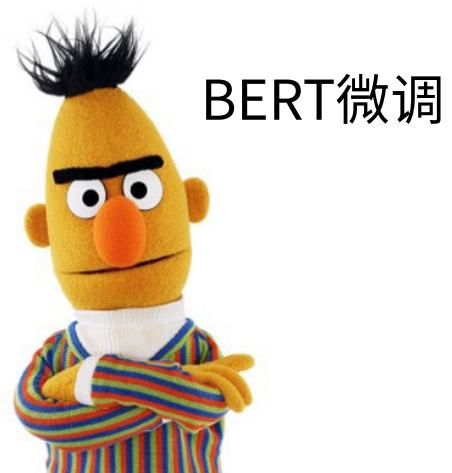

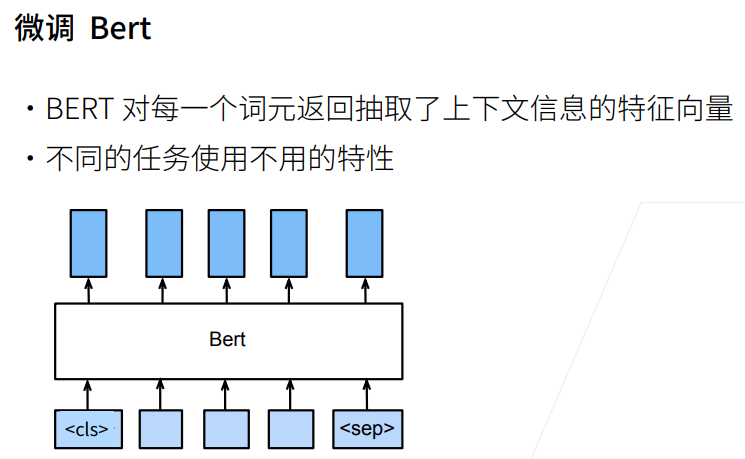

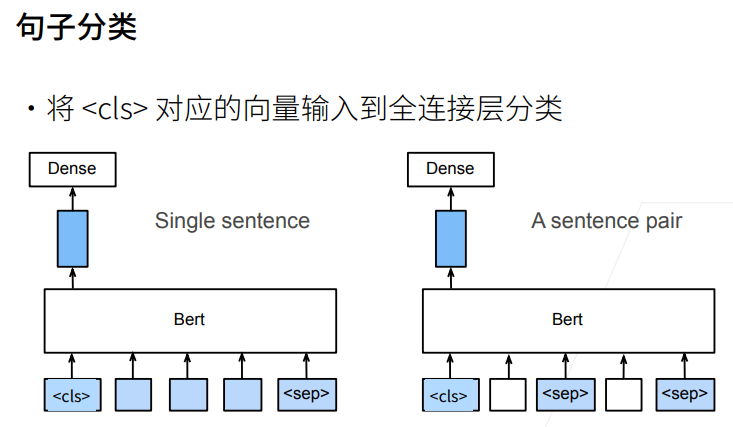

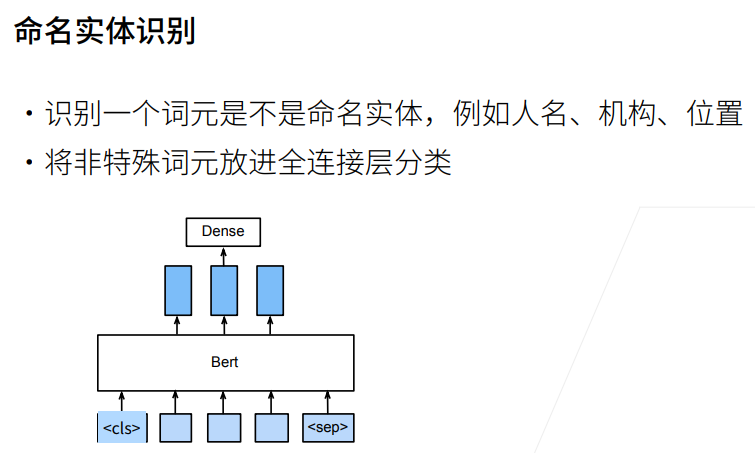

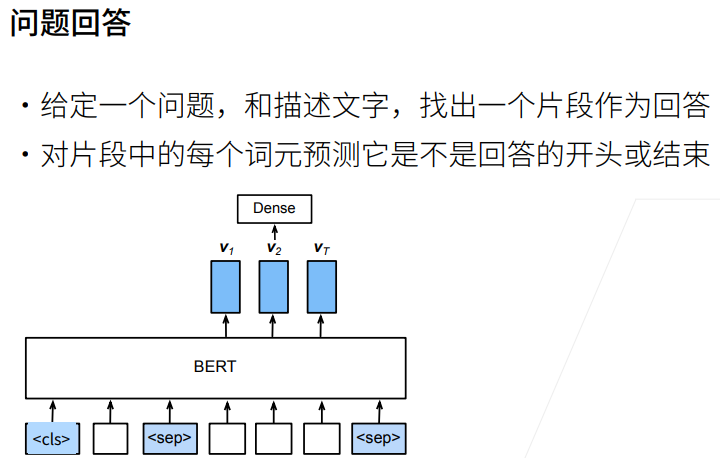

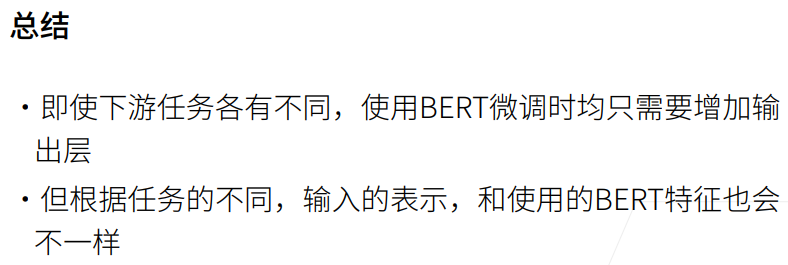

# 2. 自然语言推理和数据集

In [10]:
# Stanford Natural Language Inference(SNLI) Corpus
import os
import re
import torch
from torch import nn
from d2l import torch as d2l

# 将 SNLI 数据集添加到 d2l 的数据集存储库中
d2l.DATA_HUB['SNLI'] = ('https://nlp.stanford.edu/projects/snli/snli_1.0.zip',
                        '9fcde07509c7e87ec61c640c1b2753d9041758e4') 

# 容错：若本地已解压好 SNLI（../data/snli_1.0），直接用，避免重复下载 94MB；
# 否则才调用 d2l.download_extract 下载解压。
_snli_local = os.path.join('..', 'data', 'snli_1.0')
if os.path.exists(os.path.join(_snli_local, 'snli_1.0_train.txt')):
    data_dir = _snli_local
    print('使用本地已解压的 SNLI:', data_dir)
else:
    data_dir = d2l.download_extract('SNLI')

使用本地已解压的 SNLI: ../data/snli_1.0


In [11]:
data_dir = "../data/snli_1.0"

In [12]:
# Reading the Dataset
# 定义函数，用于处理文本数据
def read_snli(data_dir, is_train):
    """Read the SNLI dataset into premises, hypotheses, and labels. """
    # 定义函数，用于处理文本数据
    def extract_text(s):
        # 去除左括号
        s = re.sub('\\(', '', s)
        # 去除右括号
        s = re.sub('\\)', '', s)
        # 去除多余的空格
        s = re.sub('\\s{2,}', ' ', s)
        # 去除首尾空格
        return s.strip()
    # 标签映射表
    label_set = {'entailment': 0, 'contradiction': 1, 'neutral': 2}
    # 根据是否是训练集选择相应的文件名
    file_name = os.path.join(data_dir, 'snli_1.0_train.txt' 
                             if is_train else 'snli_1.0_test.txt')
    # 打开文件并逐行读取数据
    with open(file_name, 'r') as f:
        rows = [row.split('\t') for row in f.readlines()[1:]]
    # 提取前提、假设和标签
    premises = [extract_text(row[1]) for row in rows if row[0] in label_set]
    hypotheses = [extract_text(row[2]) for row in rows if row[0] in label_set]
    labels = [label_set[row[0]] for row in rows if row[0] in label_set]
    return premises, hypotheses, labels

In [13]:
# Print the first 3 pairs
# 打印前三对数据
train_data = read_snli(data_dir, is_train=True)
for x0, x1, y in zip(train_data[0][:3], train_data[1][:3], train_data[2][:3]):
    print('premise:', x0)
    print('hypothesis:', x1)
    print('label:', y)

premise: A person on a horse jumps over a broken down airplane .
hypothesis: A person is training his horse for a competition .
label: 2
premise: A person on a horse jumps over a broken down airplane .
hypothesis: A person is at a diner , ordering an omelette .
label: 1
premise: A person on a horse jumps over a broken down airplane .
hypothesis: A person is outdoors , on a horse .
label: 0


In [14]:
# Labels "entailment", "contradiction", and "neutral" are balanced
# 标签 "entailment"、"contradiction" 和 "neutral" 均衡
test_data = read_snli(data_dir, is_train=False)
for data in [train_data, test_data]:
    # 打印结果显示了各个标签在数据集中的出现次数，用于验证它们是否均衡
    print([[row for row in data[2]].count(i) for i in range(3)])

[183416, 183187, 182764]
[3368, 3237, 3219]


In [15]:
# Defining a Class for Loading the Dataset
class SNLIDataset(torch.utils.data.Dataset):
    """A customized dataset to load the SNLI dataset"""
    # 初始化方法
    def __init__(self, dataset, num_steps, vocab=None):
        self.num_steps = num_steps
        # 分词得到前提的标记列表
        all_premise_tokens = d2l.tokenize(dataset[0])
        # 分词得到假设的标记列表
        all_hypothesis_tokens = d2l.tokenize(dataset[1])
        if vocab is None:
            # 构建词汇表
            self.vocab = d2l.Vocab(all_premise_tokens + all_hypothesis_tokens,
                                   min_freq=5, reserved_tokens=['<pad>']) 
        else:
            self.vocab = vocab
        # 填充后的前提标记张量
        self.premises = self._pad(all_premise_tokens)
        # 填充后的假设标记张量
        self.hypotheses = self._pad(all_hypothesis_tokens)
        # 标签张量
        self.labels = torch.tensor(dataset[2])
        print('read ' + str(len(self.premises)) + ' examles')
        
    def _pad(self, lines):
        # 辅助方法，对标记列表进行填充
        return torch.tensor([d2l.truncate_pad(
            self.vocab[line],self.num_steps,self.vocab['<pad>'])
                            for line in lines])
    
    def __getitem__(self, idx):
        # 获取数据项的方法
        return (self.premises[idx], self.hypotheses[idx]), self.labels[idx] 
    
    def __len__(self):
        # 返回数据集的长度
        return len(self.premises)

In [16]:
class SNLIDataset(torch.utils.data.Dataset):
    """A customized dataset to load the SNLI dataset."""
    # 初始化方法
    def __init__(self, dataset, num_steps, vocab=None):
        self.num_steps = num_steps
        # 对前提进行分词得到标记列表
        all_premise_tokens = d2l.tokenize(dataset[0])
        # 对假设进行分词得到标记列表
        all_hypothesis_tokens = d2l.tokenize(dataset[1])
        if vocab is None:
            # 构建词汇表对象
            self.vocab = d2l.Vocab(all_premise_tokens + all_hypothesis_tokens,
                                   min_freq=5, reserved_tokens=['<pad>'])
        else:
            self.vocab = vocab
        # 填充后的前提标记张量
        self.premises = self._pad(all_premise_tokens)
        # 填充后的假设标记张量
        self.hypotheses = self._pad(all_hypothesis_tokens)
        # 标签张量
        self.labels = torch.tensor(dataset[2])
        print('read ' + str(len(self.premises)) + ' examples')

    def _pad(self, lines):
        # 辅助方法，对标记列表进行填充
        return torch.tensor([d2l.truncate_pad(
            self.vocab[line], self.num_steps, self.vocab['<pad>'])
                         for line in lines])

    def __getitem__(self, idx):
        # 获取数据项的方法
        return (self.premises[idx], self.hypotheses[idx]), self.labels[idx]

    def __len__(self):
        # 返回数据集的长度
        return len(self.premises)

In [17]:
# Putting All Things Together
def load_data_snli(batch_size, num_steps=50):
    """Download the SNLI dataset and return data iterators and vocabulary."""  
    num_workers = 0
    data_dir = "../data/snli_1.0"
    # 读取训练集数据
    train_data = read_snli(data_dir, True)
    # 读取测试集数据
    test_data = read_snli(data_dir, False)
    # 创建训练集数据集对象
    train_set = SNLIDataset(train_data, num_steps)
    # 创建测试集数据集对象，并共享训练集的词汇表
    test_set = SNLIDataset(test_data, num_steps, train_set.vocab)
    # 创建训练集数据迭代器
    train_iter = torch.utils.data.DataLoader(train_set, batch_size, 
                                             shuffle=True, num_workers=num_workers)    
    # 创建测试集数据迭代器
    test_iter = torch.utils.data.DataLoader(test_set, batch_size, 
                                            shuffle=False, num_workers=num_workers)   
    return train_iter, test_iter, train_set.vocab

# 加载数据迭代器和词汇表
train_iter, test_iter, vocab = load_data_snli(128, 50)
# 词汇表的大小
len(vocab)

read 549367 examples
read 9824 examples


18678

In [18]:
for X, Y in train_iter:
    # 打印训练集中输入数据的形状（premises）
    print(X[0].shape)
    # 打印训练集中输入数据的形状（hypotheses）
    print(X[1].shape)
    # 打印训练集中标签数据的形状
    print(Y.shape)
    # 仅打印第一个批次的数据，然后退出循环
    break

torch.Size([128, 50])
torch.Size([128, 50])
torch.Size([128])


# 3. 自然语言推理：微调BERT

In [19]:
import json
import multiprocessing
import os
import torch
from torch import nn
from d2l import torch as d2l

In [20]:
# Loading Pretrained BERT
# 定义预训练的BERT模型的数据源链接和哈希值
d2l.DATA_HUB['bert.base'] = (d2l.DATA_URL + 'bert.base.torch.zip', 
                             '225d66f04cae318b841a13d32af3acc165f253ac')
d2l.DATA_HUB['bert.small'] = (d2l.DATA_URL + 'bert.small.torch.zip',
                              'c72329e68a732bef0452e4b96a1c341c8910f81f')

In [21]:
# Load pretrained BERT parameters
def load_pretrained_model(pretrained_model, num_hiddens, ffn_num_hiddens,
                          num_heads, num_layers, dropout, max_len, devices):
    # 下载和提取预训练模型的数据文件
    data_dir = d2l.download_extract(pretrained_model)
    # 创建词汇表对象，并加载词汇表索引和标记的映射关系
    vocab = d2l.Vocab()
    vocab.idx_to_token = json.load(open(os.path.join(data_dir, 'vocab.json')))  
    vocab.token_to_idx = {token: idx for idx, token in enumerate(vocab.idx_to_token)}   
    # 创建BERT模型对象
    bert = d2l.BERTModel(len(vocab), num_hiddens, norm_shape=[256],
                         ffn_num_input=256, ffn_num_hiddens=ffn_num_hiddens,
                         num_heads=4,num_layers=2,dropout=0.2,
                         max_len=max_len,key_size=256,query_size=256,
                         value_size=256,hid_in_features=256,
                         mlm_in_features=256,nsp_in_features=256)
    # 加载预训练的BERT参数
    bert.load_state_dict(torch.load(os.path.join(data_dir, 'pretrained.params')))  
    return bert, vocab
# 尝试使用所有可用的GPU设备
devices = d2l.try_all_gpus()
# 加载预训练的BERT模型和词汇表
bert, vocab = load_pretrained_model(
    'bert.small', num_hiddens=256, ffn_num_hiddens=512, num_heads=4,
    num_layers=2, dropout=0.1, max_len=512, devices=devices)

/tmp/ipykernel_1621517/1920639727.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bert.load_state_dict(torch.load(os.path.join(data_dir, 'pretrained.params')))


In [22]:
# The Dataset for Fine-Tuning BERT
class SNLIBERTDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, max_len, vocab=None):
        # 将前提和假设的文本转换为词元序列，并存储在all_premise_hypothesis_tokens中
        all_premise_hypothesis_tokens = [[
            p_tokens, h_tokens] for p_tokens, h_tokens in zip(
            *[d2l.tokenize([s.lower() for s in sentences]) 
              for sentences in dataset[:2]])]
        # 存储标签
        self.labels = torch.tensor(dataset[2])
        self.vocab = vocab
        self.max_len = max_len
        # 对所有前提和假设的词元序列进行预处理
        (self.all_token_ids, self.all_segments, 
         self.valid_lens) = self._preprocess(all_premise_hypothesis_tokens)   
        print('read ' + str(len(self.all_token_ids)) + ' examples')
    
    def _preprocess(self, all_premise_hypothesis_tokens):
        # 多进程处理词元序列
        out = map(self._mp_worker, all_premise_hypothesis_tokens)
        out = list(out)
        # 提取预处理后的结果
        all_token_ids = [token_ids for token_ids, segments, valid_len in out]   
        all_segments = [segments for token_ids, segments, valid_len in out]
        valid_lens = [valid_len for token_ids, segments, valid_len in out]
        return (torch.tensor(all_token_ids, dtype=torch.long),
                torch.tensor(all_segments, dtype=torch.long),
                torch.tensor(valid_lens))
    
    def _mp_worker(self, premise_hypothesis_tokens):
        # 处理单个前提和假设的词元序列
        p_tokens, h_tokens = premise_hypothesis_tokens
        # 截断前提和假设的词元序列
        self._truncate_pair_of_tokens(p_tokens, h_tokens)
        # 获取词元和片段标记
        tokens, segments = d2l.get_tokens_and_segments(p_tokens, h_tokens) 
        # 将词元序列转换为索引序列，补齐至最大长度
        token_ids = self.vocab[tokens] + [self.vocab['<pad>']] * (self.max_len - len(tokens))   
        # 补齐片段标记至最大长度
        segments = segments + [0] * (self.max_len - len(segments))
        # 记录有效长度
        valid_len = len(tokens)
        return token_ids, segments, valid_len
    
    def _truncate_pair_of_tokens(self, p_tokens, h_tokens):
        # 不断截断前提和假设的词元序列，使总长度不超过最大长度减3
        while len(p_tokens) + len(h_tokens) > self.max_len - 3:
            if len(p_tokens) > len(h_tokens):
                p_tokens.pop()
            else:
                h_tokens.pop()
                
    def __getitem__(self, idx):
        # 返回数据样本和标签
        return (self.all_token_ids[idx], self.all_segments[idx], 
                self.valid_lens[idx]), self.labels[idx]
    
    def __len__(self):
        # 返回数据集的样本数量
        return len(self.all_token_ids)

In [23]:
# Generate training and testing examples
# 生成训练和测试样本
batch_size, max_len, num_workers = 512, 128, 0
data_dir = "../data/snli_1.0"
# 创建训练集和测试集的 SNLIBERTDataset 对象
train_set = SNLIBERTDataset(d2l.read_snli(data_dir, True), max_len, vocab)  
test_set = SNLIBERTDataset(d2l.read_snli(data_dir, False), max_len, vocab)   
# 创建训练集和测试集的数据迭代器
train_iter = torch.utils.data.DataLoader(train_set, batch_size, shuffle=True, num_workers = num_workers)
test_iter = torch.utils.data.DataLoader(test_set, batch_size, num_workers = num_workers)    

read 549367 examples
read 9824 examples


In [24]:
# This MLP transforms the BERT representation of the special "<cls>" token into three outputs of natural language inference
# 定义一个 MLP，将特殊的 "<cls>" 标记的 BERT 表示转换为三个自然语言推断的输出
class BERTClassifier(nn.Module):
    def __init__(self, bert):
        super(BERTClassifier, self).__init__()
        # BERT 编码器
        self.encoder = bert.encoder
        # BERT 隐藏层
        self.hidden = bert.hidden
        # 输出层，将隐藏层的输出映射到三个类别
        self.output = nn.Linear(256, 3)
        
    def forward(self, inputs):
        # 输入数据
        tokens_X, segments_X, valid_lens_x = inputs
        # BERT 编码器的输出
        encoded_X = self.encoder(tokens_X, segments_X, valid_lens_x)
        # 将特殊标记的表示进行线性变换得到最终输出
        return self.output(self.hidden(encoded_X[:, 0, :]))
    
# 创建 BERTClassifier 对象
net = BERTClassifier(bert)

loss 0.520, train acc 0.791, test acc 0.784
13806.3 examples/sec on [device(type='cuda', index=0)]


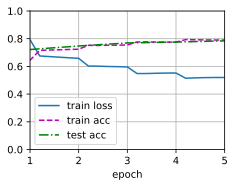

In [25]:
# The training
# 训练过程
# 学习率和训练轮数
lr, num_epochs = 1e-4, 5
# Adam 优化器
trainer = torch.optim.Adam(net.parameters(), lr=lr)
# 交叉熵损失函数，不进行降维
loss = nn.CrossEntropyLoss(reduction='none')
# 调用 d2l.train_ch13 函数进行模型的训练
d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)   